# Telco Customer Churn Prediction

## Data Preparation and Model Comparison

The four models are compared using the same experimental setup:

- the same stratified 80/20 train-test split;
- the same 5-fold stratified cross-validation;
- the same F1-score for hyperparameter selection;
- StandardScaler and SMOTE fitted inside each cross-validation fold;
- the same untouched test set for final evaluation;
- the same evaluation metrics: Accuracy, Precision, Recall, F1-score and ROC-AUC.

Using a pipeline prevents information from the validation folds from being used during scaling or SMOTE.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

# Load and clean the dataset
df = pd.read_csv("Telco_Cusomer_Churn.csv")
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convert categorical variables into numerical form
df_encoded = pd.get_dummies(df, drop_first=True).astype(int)

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Use one train-test split for every model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Numerical columns that require standardisation
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Scale numerical columns and keep the remaining encoded columns unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

# Use exactly the same cross-validation folds for all models
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Training class distribution:")
print(y_train.value_counts().to_string())

print("\nTesting class distribution:")
print(y_test.value_counts().to_string())

print(f"\nTraining records: {len(X_train)}")
print(f"Testing records : {len(X_test)}")


Training class distribution:
Churn
0    4139
1    1495

Testing class distribution:
Churn
0    1035
1     374

Training records: 5634
Testing records : 1409


In [ ]:
# Common evaluation functions

def evaluate_model(name, model):
    # The pipeline handles preprocessing automatically
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    return result, y_pred, y_proba


def print_tuning_results(search):
    print("Best parameters:")
    print(search.best_params_)
    print(f"Best cross-validation F1-score: {search.best_score_:.4f}")

    tuning_results = pd.DataFrame(search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ].sort_values("rank_test_score").head(10)

    print("\nTop tuning results:")
    display(tuning_results)


def get_feature_names(fitted_pipeline):
    return fitted_pipeline.named_steps["preprocess"].get_feature_names_out()


def show_model_results(model_name, model, y_pred, y_proba, top_n=10):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[0], cbar=False)
    axes[0].set_title(f"{model_name} - Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_value = roc_auc_score(y_test, y_proba)

    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc_value:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_title(f"{model_name} - ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    # Coefficients or feature importance
    feature_names = get_feature_names(model)
    classifier = model.named_steps["model"]

    if hasattr(classifier, "coef_"):
        values = classifier.coef_[0]
        label = "Coefficient"
    else:
        values = classifier.feature_importances_
        label = "Feature Importance"

    importance = pd.Series(values, index=feature_names)
    top_features = importance.abs().nlargest(top_n).index
    plot_values = importance.loc[top_features].sort_values()

    axes[2].barh(plot_values.index, plot_values.values)
    axes[2].set_title(f"{model_name} - Top {top_n} Features")
    axes[2].set_xlabel(label)

    plt.tight_layout()
    plt.show()


Best parameters:
{'model__C': 0.01}
Best cross-validation F1-score: 0.6323

Top tuning results:


,params,mean_test_score,std_test_score,rank_test_score
0,{'model__C': 0.01},0.632250,0.020708,1
1,{'model__C': 0.1},0.631402,0.020500,2
2,{'model__C': 1},0.630071,0.026117,3
3,{'model__C': 10},0.629340,0.023500,4
4,{'model__C': 100},0.628236,0.023126,5



Test set results:
Accuracy  : 0.7410
Precision : 0.5079
Recall    : 0.7701
F1-Score  : 0.6121
ROC-AUC   : 0.8380


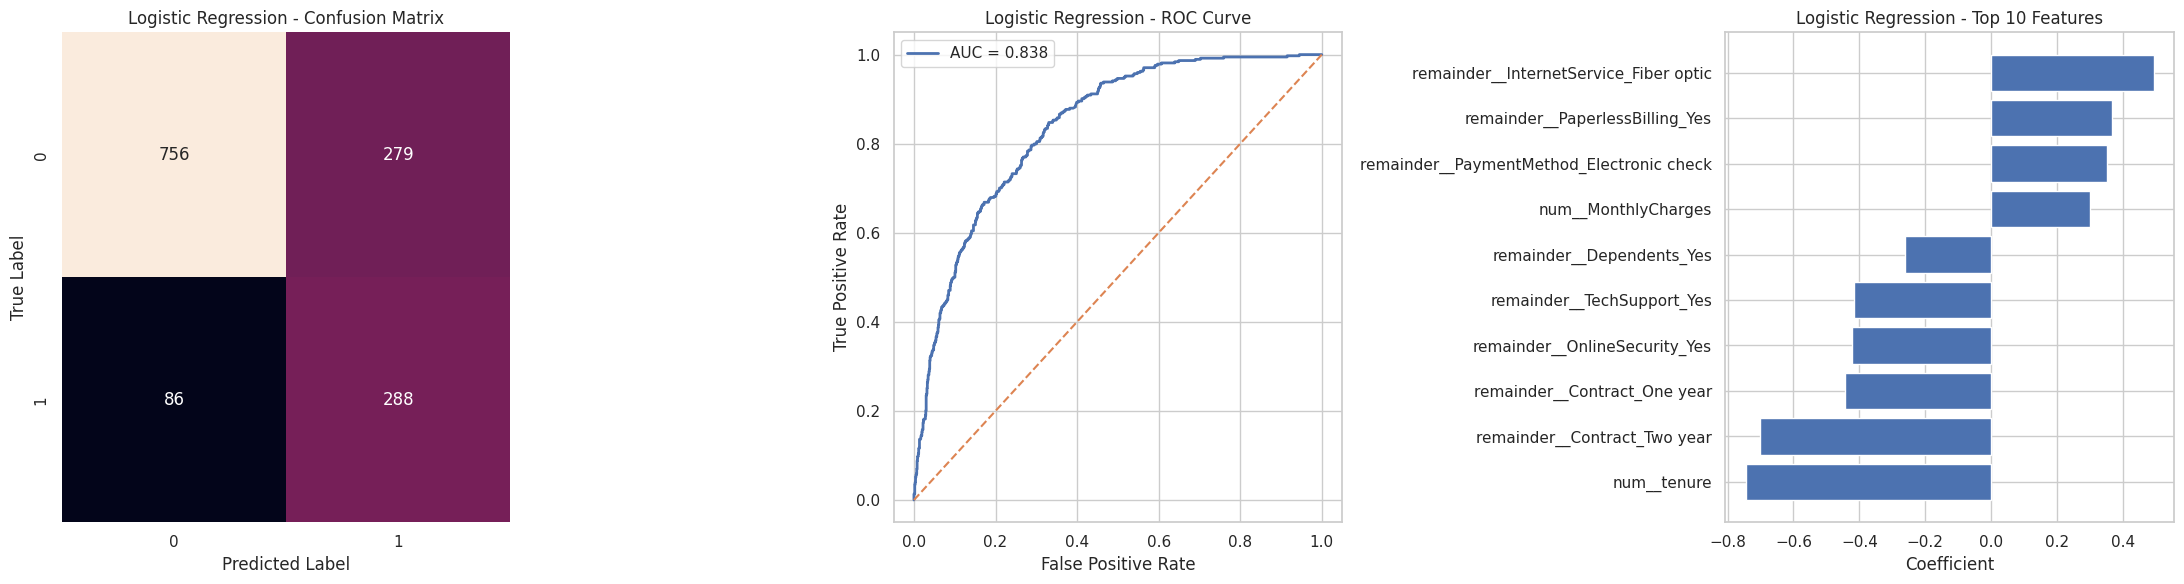

['logistic_regression_pipeline.pkl']

In [ ]:
# Logistic Regression

lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
best_log_model = lr_grid.best_estimator_

print_tuning_results(lr_grid)

lr_result, lr_pred, lr_proba = evaluate_model(
    "Logistic Regression",
    best_log_model
)

print("\nTest set results:")
for metric, value in lr_result.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

show_model_results(
    "Logistic Regression",
    best_log_model,
    lr_pred,
    lr_proba,
    top_n=10
)

joblib.dump(best_log_model, "logistic_regression_pipeline.pkl")


Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best cross-validation F1-score: 0.6089

Top tuning results:


,params,mean_test_score,std_test_score,rank_test_score
14,"{'model__max_depth': 5, 'model__min_samples_le...",0.608904,0.015887,1
12,"{'model__max_depth': 5, 'model__min_samples_le...",0.608904,0.015887,1
13,"{'model__max_depth': 5, 'model__min_samples_le...",0.608904,0.015887,1
9,"{'model__max_depth': 5, 'model__min_samples_le...",0.608360,0.016330,4
11,"{'model__max_depth': 5, 'model__min_samples_le...",0.608360,0.016330,4
10,"{'model__max_depth': 5, 'model__min_samples_le...",0.608360,0.016330,4
15,"{'model__max_depth': 5, 'model__min_samples_le...",0.606922,0.018652,7
16,"{'model__max_depth': 5, 'model__min_samples_le...",0.606922,0.018652,7
17,"{'model__max_depth': 5, 'model__min_samples_le...",0.606922,0.018652,7
20,"{'model__max_depth': 7, 'model__min_samples_le...",0.605825,0.014246,10



Test set results:
Accuracy  : 0.7410
Precision : 0.5078
Recall    : 0.7834
F1-Score  : 0.6162
ROC-AUC   : 0.8177


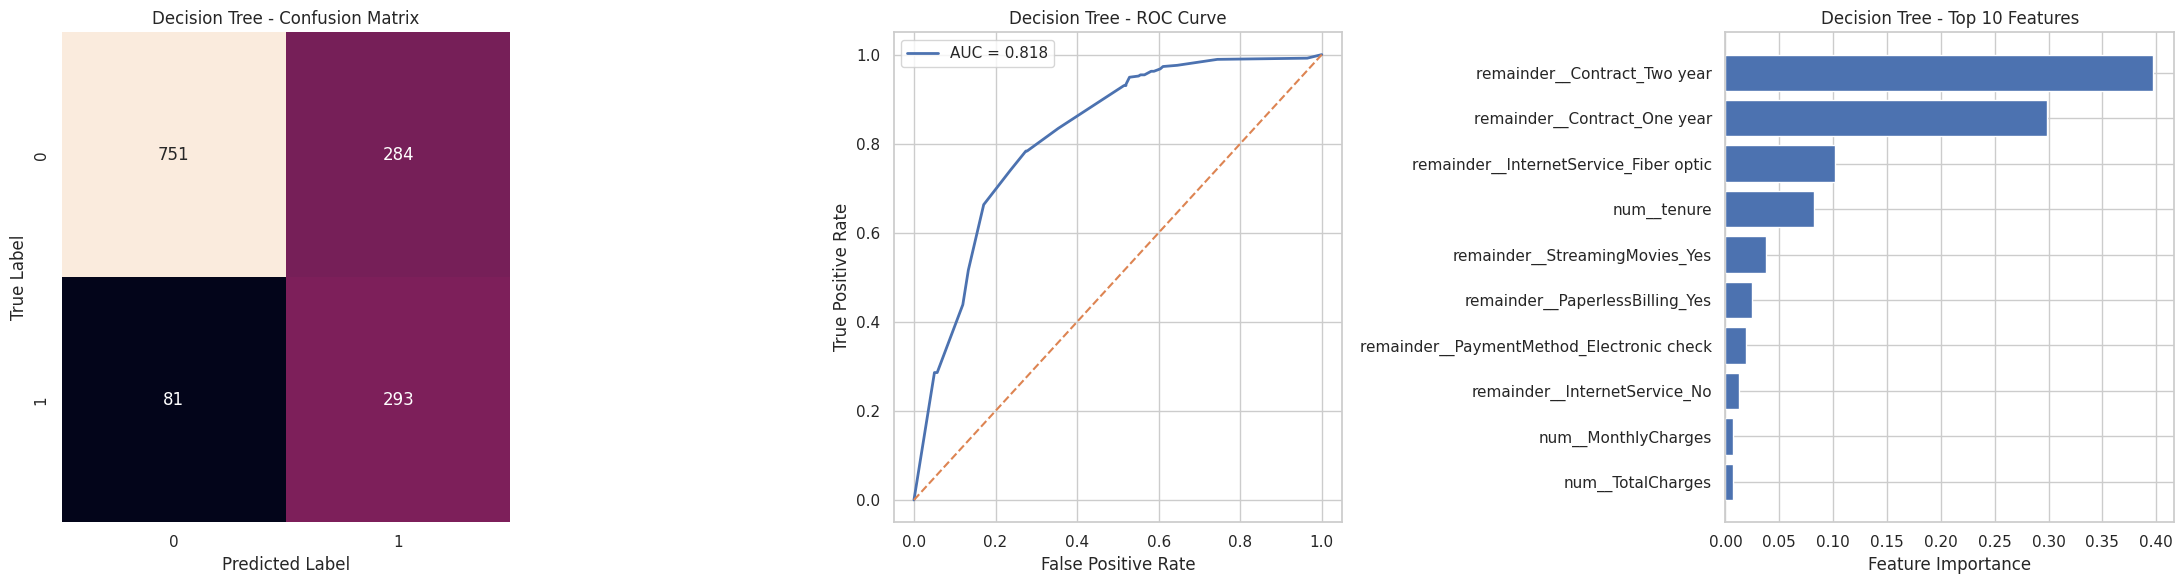

['decision_tree_pipeline.pkl']

In [ ]:
# Decision Tree

dt_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 10, 20]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
best_dt_model = dt_grid.best_estimator_

print_tuning_results(dt_grid)

dt_result, dt_pred, dt_proba = evaluate_model(
    "Decision Tree",
    best_dt_model
)

print("\nTest set results:")
for metric, value in dt_result.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

show_model_results(
    "Decision Tree",
    best_dt_model,
    dt_pred,
    dt_proba,
    top_n=10
)

joblib.dump(best_dt_model, "decision_tree_pipeline.pkl")


Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best cross-validation F1-score: 0.6360

Top tuning results:


,params,mean_test_score,std_test_score,rank_test_score
11,"{'model__max_depth': 10, 'model__min_samples_l...",0.636015,0.018417,1
12,"{'model__max_depth': 10, 'model__min_samples_l...",0.635287,0.016680,2
10,"{'model__max_depth': 10, 'model__min_samples_l...",0.633433,0.017953,3
13,"{'model__max_depth': 10, 'model__min_samples_l...",0.633333,0.017423,4
9,"{'model__max_depth': 10, 'model__min_samples_l...",0.633289,0.019261,5
15,"{'model__max_depth': 10, 'model__min_samples_l...",0.632241,0.019919,6
14,"{'model__max_depth': 10, 'model__min_samples_l...",0.631097,0.019249,7
8,"{'model__max_depth': 10, 'model__min_samples_l...",0.630545,0.020207,8
3,"{'model__max_depth': 5, 'model__min_samples_le...",0.628741,0.017735,9
4,"{'model__max_depth': 5, 'model__min_samples_le...",0.628241,0.020501,10



Test set results:
Accuracy  : 0.7679
Precision : 0.5475
Recall    : 0.7246
F1-Score  : 0.6237
ROC-AUC   : 0.8431


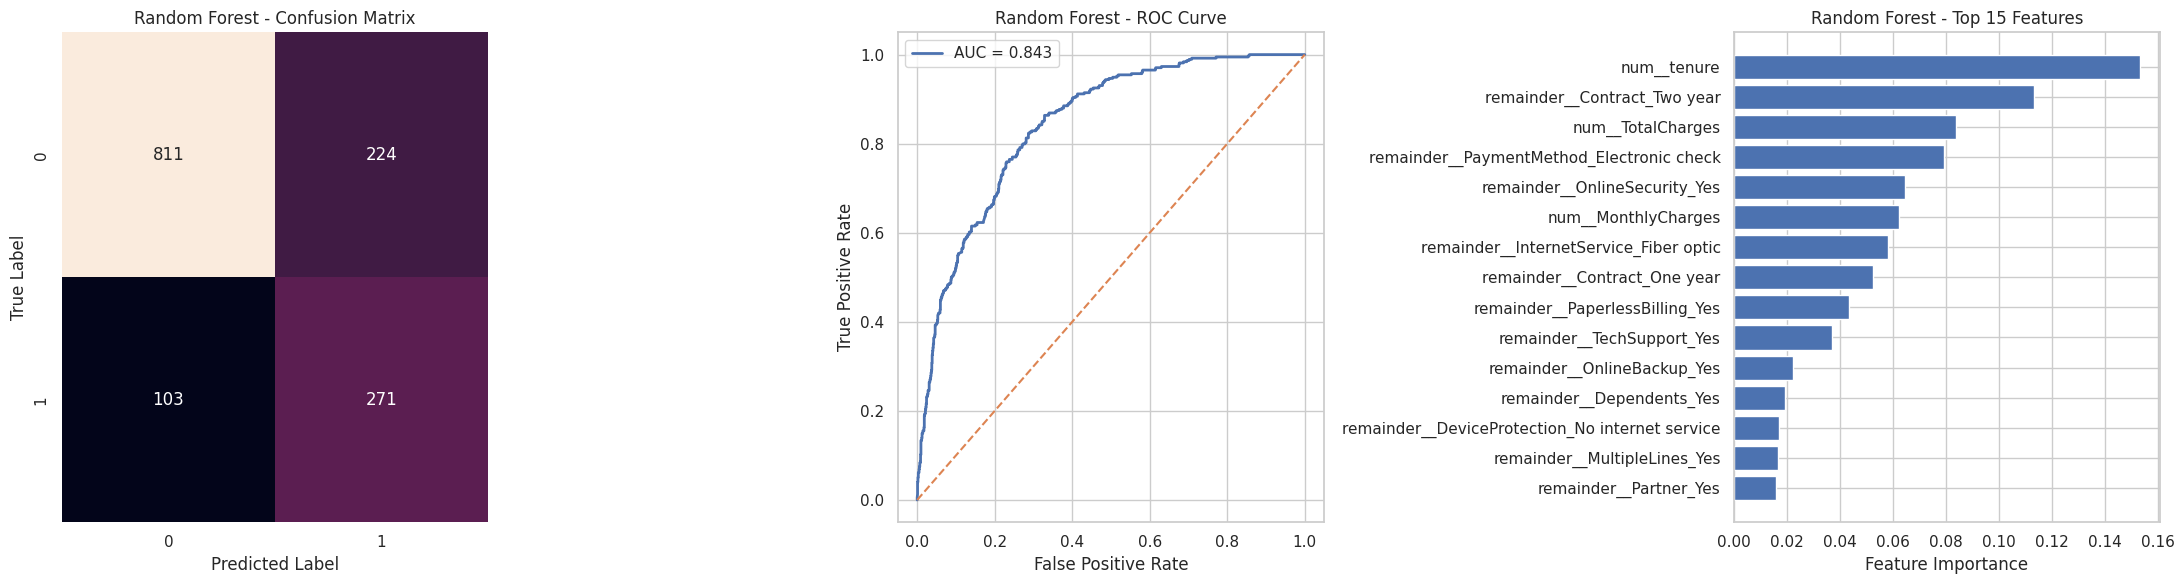

['random_forest_pipeline.pkl']

In [ ]:
# Random Forest

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

print_tuning_results(rf_grid)

rf_result, rf_pred, rf_proba = evaluate_model(
    "Random Forest",
    best_rf_model
)

print("\nTest set results:")
for metric, value in rf_result.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

show_model_results(
    "Random Forest",
    best_rf_model,
    rf_pred,
    rf_proba,
    top_n=15
)

joblib.dump(best_rf_model, "random_forest_pipeline.pkl")


Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best cross-validation F1-score: 0.6332

Top tuning results:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'model__learning_rate': 0.05, 'model__max_dep...",0.633156,0.017803,1
2,"{'model__learning_rate': 0.05, 'model__max_dep...",0.625530,0.017844,2
4,"{'model__learning_rate': 0.1, 'model__max_dept...",0.624964,0.019652,3
1,"{'model__learning_rate': 0.05, 'model__max_dep...",0.624961,0.015838,4
5,"{'model__learning_rate': 0.1, 'model__max_dept...",0.609992,0.014733,5
6,"{'model__learning_rate': 0.1, 'model__max_dept...",0.608203,0.014536,6
3,"{'model__learning_rate': 0.05, 'model__max_dep...",0.607073,0.016955,7
7,"{'model__learning_rate': 0.1, 'model__max_dept...",0.594904,0.008072,8



Test set results:
Accuracy  : 0.7672
Precision : 0.5447
Recall    : 0.7487
F1-Score  : 0.6306
ROC-AUC   : 0.8415


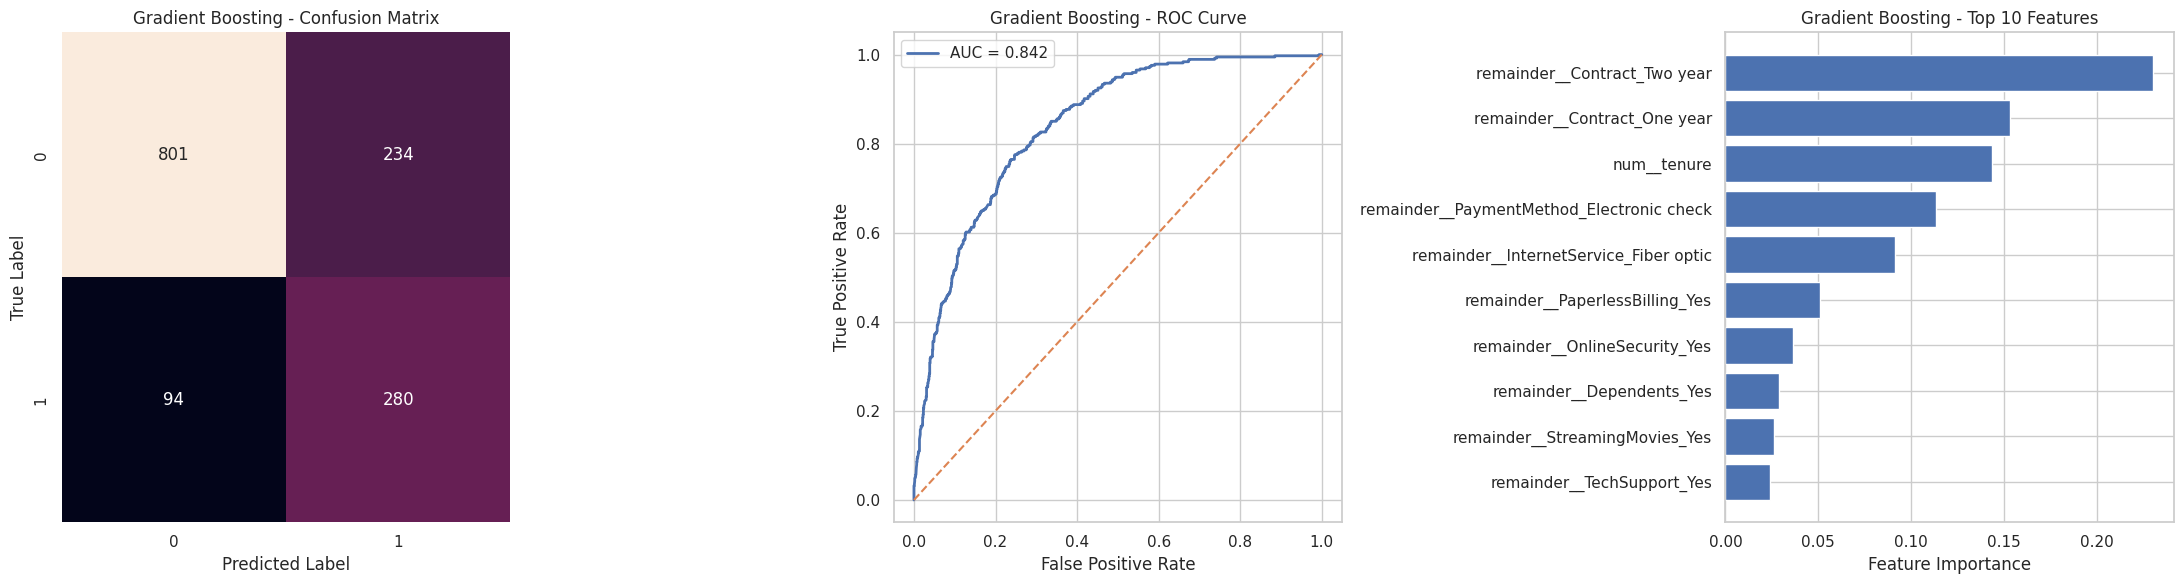

['gradient_boosting_pipeline.pkl']

In [ ]:
# Gradient Boosting

gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)
best_gb_model = gb_grid.best_estimator_

print_tuning_results(gb_grid)

gb_result, gb_pred, gb_proba = evaluate_model(
    "Gradient Boosting",
    best_gb_model
)

print("\nTest set results:")
for metric, value in gb_result.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

show_model_results(
    "Gradient Boosting",
    best_gb_model,
    gb_pred,
    gb_proba,
    top_n=10
)

joblib.dump(best_gb_model, "gradient_boosting_pipeline.pkl")


MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7410,0.5079,0.7701,0.6121,0.8380
1,Decision Tree,0.7410,0.5078,0.7834,0.6162,0.8177
2,Random Forest,0.7679,0.5475,0.7246,0.6237,0.8431
3,Gradient Boosting,0.7672,0.5447,0.7487,0.6306,0.8415



Best model for each metric:
Accuracy  : Random Forest (0.7679)
Precision : Random Forest (0.5475)
Recall    : Decision Tree (0.7834)
F1-Score  : Gradient Boosting (0.6306)
ROC-AUC   : Random Forest (0.8431)


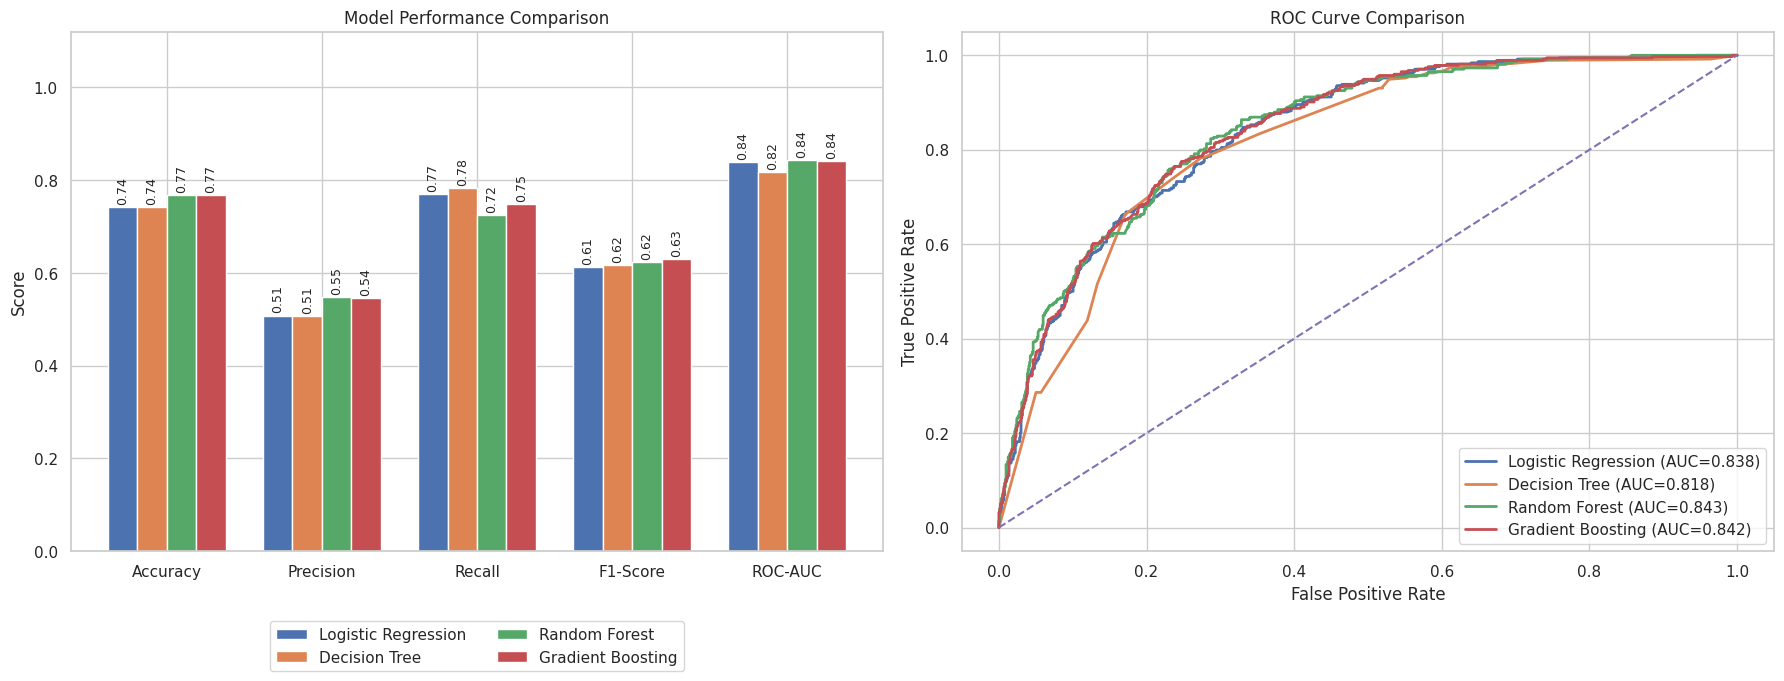

In [ ]:
# Final model comparison

results_df = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    gb_result
])

print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
display(results_df.round(4))

print("\nBest model for each metric:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    idx = results_df[metric].idxmax()
    print(
        f"{metric:10s}: "
        f"{results_df.loc[idx, 'Model']} "
        f"({results_df.loc[idx, metric]:.4f})"
    )

# Compare evaluation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.19

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, row in results_df.iterrows():
    values = [row[m] for m in metrics]
    offset = (i - 1.5) * width

    bars = axes[0].bar(
        x + offset,
        values,
        width,
        label=row["Model"]
    )

    axes[0].bar_label(
        bars,
        fmt="%.2f",
        padding=2,
        fontsize=9,
        rotation=90
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Performance Comparison")
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

# Compare ROC curves
roc_items = [
    ("Logistic Regression", lr_proba),
    ("Decision Tree", dt_proba),
    ("Random Forest", rf_proba),
    ("Gradient Boosting", gb_proba)
]

for name, probability in roc_items:
    fpr, tpr, _ = roc_curve(y_test, probability)

    auc_value = results_df.loc[
        results_df["Model"] == name,
        "ROC-AUC"
    ].iloc[0]

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC={auc_value:.3f})"
    )

axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve Comparison")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
# Select the final model based on F1-score

model_objects = {
    "Logistic Regression": best_log_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
    "Gradient Boosting": best_gb_model
}

best_index = results_df["F1-Score"].idxmax()
final_model_name = results_df.loc[best_index, "Model"]

final_model = model_objects[final_model_name]

print("Final model selected:", final_model_name)
print(
    "Test F1-score:",
    round(results_df.loc[best_index, "F1-Score"], 4)
)

joblib.dump(final_model, "final_churn_model.pkl")

Final model selected: Gradient Boosting
Test F1-score: 0.6306


['final_churn_model.pkl']

In [ ]:
# ================================
# Generate Demo Customer Portfolio
# ================================

import pandas as pd

# Reload original dataset
customer_data = pd.read_csv("Telco_Cusomer_Churn.csv")

# Recreate the same stratified test split
from sklearn.model_selection import train_test_split

X = customer_data.drop("Churn", axis=1)
y = customer_data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create demo customer portfolio from unseen test customers
demo_customer_portfolio = X_test.copy()

# Save for Streamlit application
demo_customer_portfolio.to_csv(
    "demo_customer_portfolio.csv",
    index=False
)

print(
    "Demo customer portfolio created:",
    demo_customer_portfolio.shape
)

Demo customer portfolio created: (1409, 20)


## Business Interpretation

The final model should not be selected from accuracy alone. Recall is important because a false negative means that a real churner may be missed. Precision is also important because low precision may cause the company to spend retention resources on customers who were not actually likely to leave.

F1-score is useful when the company wants a balance between detecting churners and controlling false alarms. ROC-AUC provides additional evidence about the model's overall ability to separate churners from non-churners.

The recommended model should therefore be selected from the actual test results. If the cost of losing a customer is much higher than the cost of contacting a non-churner, Recall can be given more importance. If retention offers are expensive, Precision and F1-score become more important.
